# ⚡ Drive2Zero
## Forecasting Sri Lanka's Transport CO₂ Emissions & EV Adoption

**Team: Tech Wizards 2.0** | Data Odyssey 2025 | General Sir John Kotelawala Defence University

| Member | Index No. |
|---|---|
| JAC Sudarshika | D/DBA/23/0011 |
| OM Kavishan | D/DBA/23/0012 |
| SAHI Piyathilaka | D/DBA/23/0031 |
| KKASCW Bandara | D/DBA/23/0037 |

---
**SDG 11** — Sustainable Cities | **SDG 13** — Climate Action

## Table of Contents
1. [Install & Imports](#1)
2. [Data Loading & Preprocessing](#2)
3. [Exploratory Data Analysis](#3)
4. [CO2 Emission Estimation](#4)
5. [Time Series Forecasting — ARIMA](#5)
6. [EV Adoption Scenario Simulation](#6)
7. [Model Validation & ML Benchmark](#7)
8. [Export Data for Power BI](#8)
9. [Executive Summary Chart](#9)

---
## 1. Install & Imports <a id='1'></a>

In [1]:
# Run this cell first — installs all required packages
import subprocess, sys
pkgs = ['ipywidgets','statsmodels','scikit-learn','openpyxl','matplotlib','seaborn','numpy','pandas']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages ready.')

All packages ready.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import math
import openpyxl

from matplotlib.gridspec import GridSpec
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display, HTML

# Plot style — dark theme
plt.rcParams.update({
    'figure.facecolor': '#0f172a', 'axes.facecolor': '#1e293b',
    'axes.edgecolor': '#334155',   'axes.labelcolor': '#e2e8f0',
    'xtick.color': '#94a3b8',      'ytick.color': '#94a3b8',
    'text.color': '#e2e8f0',       'grid.color': '#334155',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'figure.dpi': 110,             'axes.titlesize': 13,
    'axes.labelsize': 11,
})

COLORS = {
    'baseline': '#f97316', 'ev_low': '#facc15', 'ev_med': '#4ade80',
    'ev_high':  '#22d3ee', 'ev_full': '#a78bfa',
    'electric': '#34d399', 'petrol': '#fb923c',
    'diesel':   '#60a5fa', 'hybrid': '#c084fc',
}
SCEN_COLORS = [COLORS['baseline'], COLORS['ev_low'], COLORS['ev_med'],
               COLORS['ev_high'], COLORS['ev_full']]

print('Imports complete.')

Imports complete.


---
## 2. Data Loading & Preprocessing <a id='2'></a>

**Source:** Department of Motor Traffic, Sri Lanka — New Vehicles Registered by Class & Fuel Type (2008–2023)

In [4]:
# ── 2.1  Load raw Excel ───────────────────────────────────────────────────────
# Update path if your file is in a different location
RAW_FILE = "D:\\Lecture Notes\\projects\\Drive2Zero_Data Oddysy 2\\data\\new_vehicles_registered 2008-2023.xlsx"

wb   = openpyxl.load_workbook(RAW_FILE, data_only=True)
ws   = wb.active
rows = list(ws.iter_rows(min_row=3, values_only=True))

header = ['VehicleClass', 'FuelType'] + [int(c) for c in rows[0][2:] if c is not None]
years  = header[2:]

records = []
current_class = None
for row in rows[1:]:
    vc, ft = row[0], row[1]
    if vc and vc not in ('TOTAL', 'Source - Department of Motor Traffic'):
        current_class = str(vc).strip()
    if ft is None or str(ft).strip() == '':
        continue
    if current_class in ('TOTAL', 'Source - Department of Motor Traffic'):
        continue
    values = []
    for v in row[2:]:
        if v is None or str(v).strip() in ('-', '\u0335', '\u0336\u0336', ''):
            values.append(0)
        else:
            try:
                values.append(int(float(str(v))))
            except:
                values.append(0)
    records.append([current_class, str(ft).strip()] + values)

raw_df = pd.DataFrame(records, columns=header)
print(f'Raw shape: {raw_df.shape}')
raw_df.head(8)

Raw shape: (41, 18)


,VehicleClass,FuelType,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Motor Cars,Diesel,2457,1117,658,2642,5787,0,3167,2488,1898,845,623,361,273,182,297,560
1,Motor Cars,Petrol,17765,4600,22397,50810,23184,0,12226,58802,21313,15732,43917,30107,19021,2990,1093,1080
2,Motor Cars,Electric,4,2,0,4414,2571,0,100,3238,983,197,223,102,77,41,17,124
3,Motor Cars,Hybrid,0,0,0,0,0,0,23287,41100,20978,22403,36013,7663,1650,282,82,52
4,Motor Tricycles Car,Petrol,11,43,17,20,4,0,0,0,0,0,0,0,0,0,0,0
5,Motor Tricycles,Diesel,1877,2066,7361,14773,8194,0,5644,7957,1993,928,729,267,78,41,15,16
6,Motor Tricycles,Petrol,42273,34970,77753,123131,89933,0,73067,121135,54521,21468,18101,14104,6679,2034,14,5
7,Motor Tricycles,Electric,0,0,0,0,0,0,0,4,8,9,6,7,0,3,0,1


In [5]:
# ── 2.2  Reshape to long format ───────────────────────────────────────────────
long_df = raw_df.melt(
    id_vars=['VehicleClass','FuelType'], value_vars=years,
    var_name='Year', value_name='Count'
)
long_df['Year']  = long_df['Year'].astype(int)
long_df['Count'] = pd.to_numeric(long_df['Count'], errors='coerce').fillna(0).astype(int)

fuel_map = {'Diesel':'Diesel','Petrol':'Petrol','Electric':'Electric',
            'Hybrid':'Hybrid','LP Gas':'Other'}
long_df['FuelType'] = long_df['FuelType'].map(fuel_map).fillna('Other')

class_map = {
    'Motor Cars':'Cars', 'Motor Tricycles':'Three-Wheelers',
    'Motor Tricycles Car':'Three-Wheelers', 'Motor Tricycles Van':'Three-Wheelers',
    'Buses ':'Buses', 'Motor Cycles':'Motorcycles',
    'Dual purpose Vehicles':'Dual Purpose', 'Single Cab':'Single Cab',
    'Lorry - Proper':'Lorry', 'Lorry - Tractors (Prime mover)':'Lorry',
    'Lorry - Others(Folk Lift)':'Lorry',
    'Special purpose Vehicles':'Special Purpose',
    'Land vehicles-Tractor (4Wh)':'Agricultural',
    'Land vehicles-Tractor (2Wh)':'Agricultural',
    'Non-Agri. Tractor ':'Agricultural',
    'Ambulances':'Special Purpose', 'Hearses':'Special Purpose',
}
long_df['VehicleClass'] = long_df['VehicleClass'].map(class_map).fillna('Other')
long_df = long_df.groupby(['Year','VehicleClass','FuelType'], as_index=False)['Count'].sum()

print(f'Long-format shape: {long_df.shape}')
print(f'Classes: {sorted(long_df.VehicleClass.unique())}')
print(f'Fuels  : {sorted(long_df.FuelType.unique())}')
long_df.head(10)

Long-format shape: (448, 4)
Classes: ['Agricultural', 'Cars', 'Dual Purpose', 'Lorry', 'Motorcycles', 'Other', 'Single Cab', 'Special Purpose', 'Three-Wheelers']
Fuels  : ['Diesel', 'Electric', 'Hybrid', 'Other', 'Petrol']


,Year,VehicleClass,FuelType,Count
0,2008,Agricultural,Diesel,24063
1,2008,Cars,Diesel,2457
2,2008,Cars,Electric,4
3,2008,Cars,Hybrid,0
4,2008,Cars,Petrol,17765
5,2008,Dual Purpose,Diesel,1450
6,2008,Dual Purpose,Electric,0
7,2008,Dual Purpose,Hybrid,0
8,2008,Dual Purpose,Petrol,1406
9,2008,Lorry,Diesel,11617


In [6]:
# ── 2.3  Yearly summary tables ────────────────────────────────────────────────
yearly_total = long_df.groupby('Year')['Count'].sum().reset_index(name='TotalVehicles')
fuel_yearly  = long_df.groupby(['Year','FuelType'])['Count'].sum().unstack(fill_value=0)
class_yearly = long_df.groupby(['Year','VehicleClass'])['Count'].sum().unstack(fill_value=0)

display(HTML('<h4>Yearly Vehicle Registrations (2008–2023)</h4>'))
display(yearly_total)
display(HTML('<h4>By Fuel Type (pivot)</h4>'))
display(fuel_yearly)

,Year,TotalVehicles
0,2008,263318
1,2009,202632
2,2010,356650
3,2011,521805
4,2012,393554
5,2013,0
6,2014,427165
7,2015,665599
8,2016,491518
9,2017,447535


FuelType,Diesel,Electric,Hybrid,Other,Petrol
Year,,,,,
2008,43183,6,0,0,220129
2009,25993,3,0,0,176636
2010,49580,10,0,0,307060
2011,85540,4440,0,0,431825
2012,80779,2623,0,0,310152
2013,0,0,0,0,0
2014,44861,301,23295,0,358708
2015,64306,3447,41129,0,556717
2016,52196,1355,20982,0,416985


---
## 3. Exploratory Data Analysis <a id='3'></a>

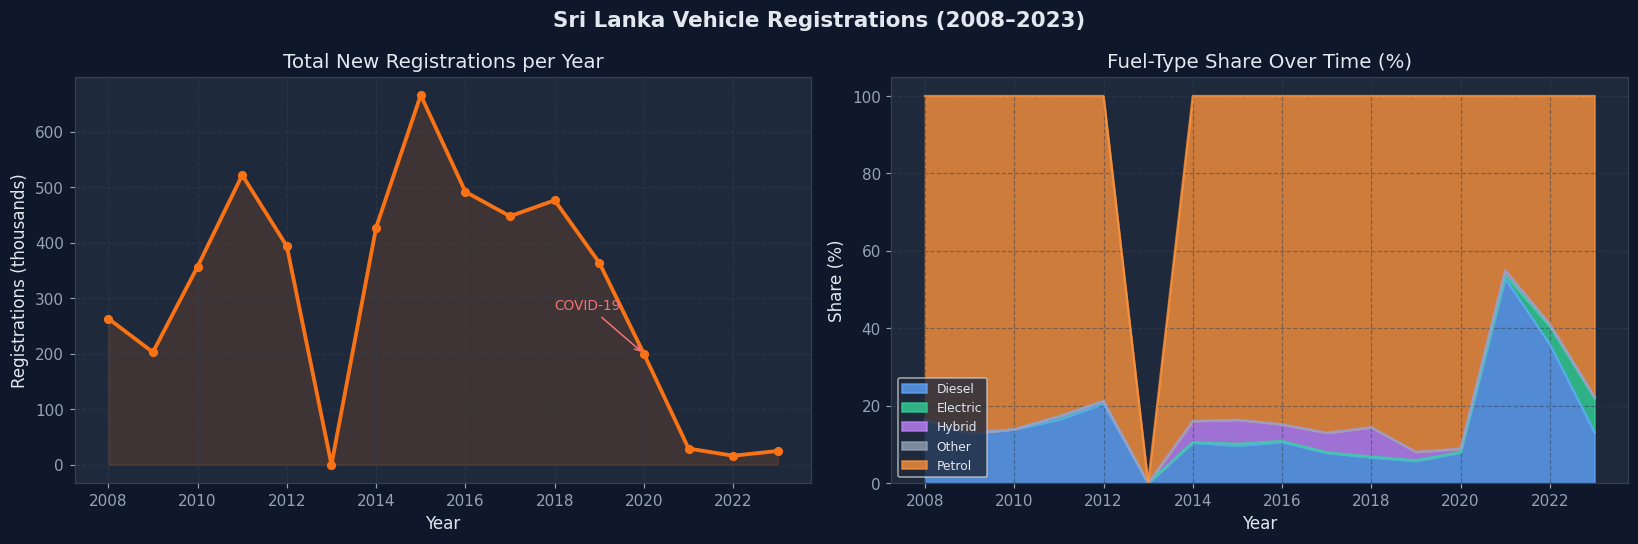

In [7]:
# ── 3.1  Total registrations & fuel share ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Sri Lanka Vehicle Registrations (2008–2023)', fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.plot(yearly_total['Year'], yearly_total['TotalVehicles']/1e3,
         color=COLORS['baseline'], lw=2.5, marker='o', ms=5)
ax1.fill_between(yearly_total['Year'], yearly_total['TotalVehicles']/1e3,
                 alpha=0.15, color=COLORS['baseline'])
ax1.set_title('Total New Registrations per Year')
ax1.set_xlabel('Year')
ax1.set_ylabel('Registrations (thousands)')
ax1.grid(True)
covid_y = yearly_total[yearly_total.Year==2020]['TotalVehicles'].values[0]/1e3
ax1.annotate('COVID-19', xy=(2020, covid_y), xytext=(2018, covid_y+80),
             arrowprops=dict(arrowstyle='->', color='#f87171'), color='#f87171', fontsize=9)

ax2 = axes[1]
fuel_pct = fuel_yearly.div(fuel_yearly.sum(axis=1), axis=0) * 100
fuel_colors = [COLORS.get(f.lower(), '#94a3b8') for f in fuel_pct.columns]
fuel_pct.plot(kind='area', ax=ax2, stacked=True, color=fuel_colors, alpha=0.8)
ax2.set_title('Fuel-Type Share Over Time (%)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Share (%)')
ax2.legend(loc='lower left', fontsize=8)
ax2.grid(True)

plt.tight_layout()
plt.savefig('fig_registrations_overview.png', bbox_inches='tight', facecolor='#0f172a')
plt.show()

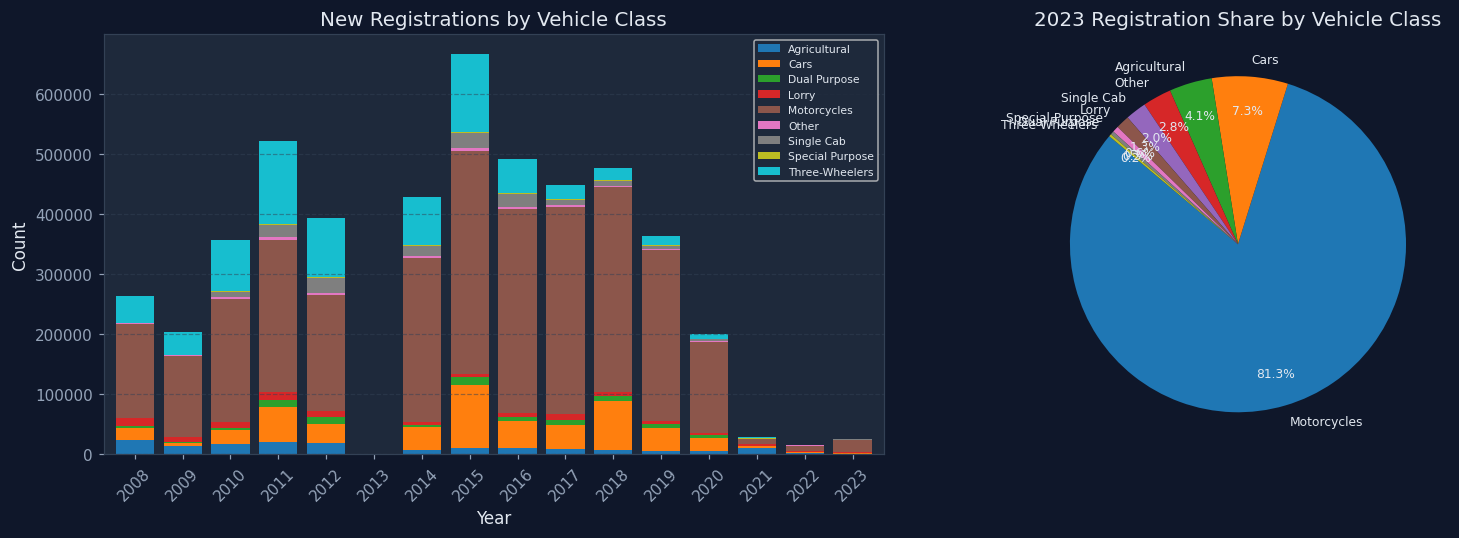

In [8]:
# ── 3.2  Vehicle class breakdown ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

class_yearly.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', width=0.8)
axes[0].set_title('New Registrations by Vehicle Class')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=7, loc='upper right')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, axis='y')

latest = long_df[long_df.Year==2023].groupby('VehicleClass')['Count'].sum()
latest = latest[latest>0].sort_values(ascending=False)
axes[1].pie(latest, labels=latest.index, autopct='%1.1f%%', startangle=140,
            colors=plt.cm.tab10.colors[:len(latest)],
            textprops={'fontsize': 8}, pctdistance=0.8)
axes[1].set_title('2023 Registration Share by Vehicle Class')

plt.tight_layout()
plt.savefig('fig_vehicle_classes.png', bbox_inches='tight', facecolor='#0f172a')
plt.show()

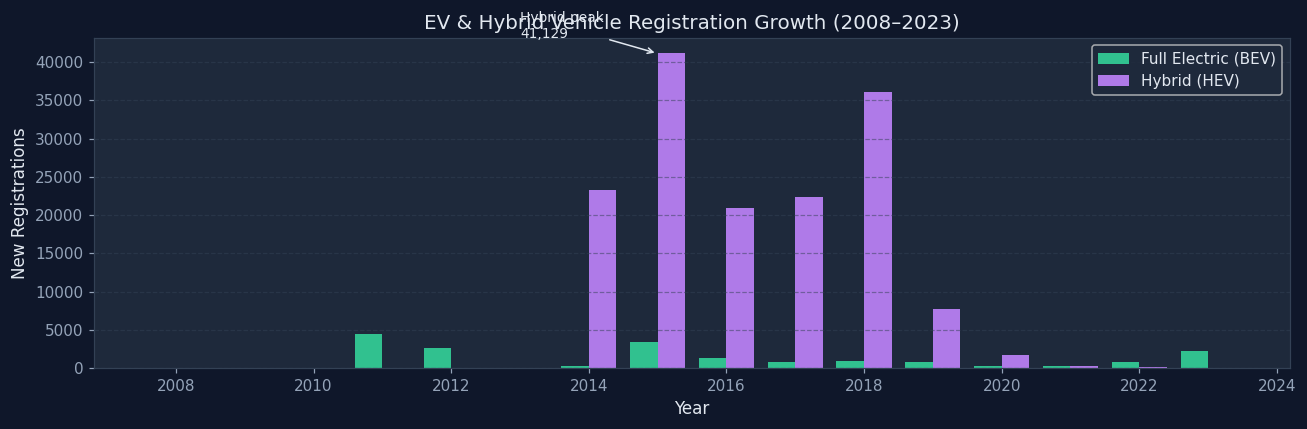

In [9]:
# ── 3.3  EV & Hybrid growth ────────────────────────────────────────────────────
ev_trend     = long_df[long_df.FuelType=='Electric'].groupby('Year')['Count'].sum().reset_index()
hybrid_trend = long_df[long_df.FuelType=='Hybrid'].groupby('Year')['Count'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(ev_trend['Year']-0.2,     ev_trend['Count'],     width=0.4,
       color=COLORS['electric'], label='Full Electric (BEV)', alpha=0.9)
ax.bar(hybrid_trend['Year']+0.2, hybrid_trend['Count'], width=0.4,
       color=COLORS['hybrid'],   label='Hybrid (HEV)',        alpha=0.9)
ax.set_title('EV & Hybrid Vehicle Registration Growth (2008–2023)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('New Registrations')
ax.legend()
ax.grid(True, axis='y')

if len(hybrid_trend) > 0:
    pk = hybrid_trend.loc[hybrid_trend['Count'].idxmax()]
    ax.annotate(f"Hybrid peak\n{int(pk['Count']):,}",
                xy=(pk['Year'], pk['Count']),
                xytext=(pk['Year']-2, pk['Count']+2000),
                arrowprops=dict(arrowstyle='->', color='#e2e8f0'), color='#e2e8f0', fontsize=9)

plt.tight_layout()
plt.savefig('fig_ev_growth.png', bbox_inches='tight', facecolor='#0f172a')
plt.show()

---
## 4. CO2 Emission Estimation <a id='4'></a>

**Formula:** CO2 (tonnes) = Vehicles x Avg km/yr x Fuel consumption (L/km) x Emission factor (kg CO2/L) / 1000

**Source:** IPCC AR6 WG3 Tier 1 emission factors. Sri Lanka grid emission factor: 0.65 kg CO2/kWh (2023).

In [10]:
# ── 4.1  Emission factor lookup table ─────────────────────────────────────────
emission_factors = pd.DataFrame({
    'VehicleClass': ['Cars','Cars','Cars','Cars',
                     'Three-Wheelers','Three-Wheelers','Three-Wheelers',
                     'Buses','Buses',
                     'Motorcycles','Motorcycles','Motorcycles',
                     'Lorry','Lorry',
                     'Dual Purpose','Dual Purpose','Dual Purpose',
                     'Single Cab','Single Cab',
                     'Agricultural','Special Purpose','Other'],
    'FuelType':     ['Petrol','Diesel','Electric','Hybrid',
                     'Petrol','Diesel','Electric',
                     'Diesel','Petrol',
                     'Petrol','Electric','Hybrid',
                     'Diesel','Petrol',
                     'Diesel','Petrol','Electric',
                     'Diesel','Petrol',
                     'Diesel','Diesel','Diesel'],
    'avg_km_yr':    [18000,18000,18000,18000,25000,25000,25000,
                     60000,60000,10000,10000,10000,40000,40000,
                     20000,20000,20000,30000,30000,3000,20000,20000],
    'fuel_per_100km':[9.0,7.5,0.0,5.5,4.5,4.0,0.0,35.0,30.0,
                      3.5,0.0,2.5,28.0,18.0,12.0,11.0,0.0,12.0,10.0,
                      8.0,15.0,12.0],
    'kwh_per_100km':[0,0,18.0,0,0,0,8.0,0,0,0,3.0,0,0,0,
                     0,0,20.0,0,0,0,0,0],
    'ef_kg_per_L':  [2.31,2.68,0.0,2.31,2.31,2.68,0.0,2.68,2.31,
                     2.31,0.0,2.31,2.68,2.31,2.68,2.31,0.0,2.68,2.31,
                     2.68,2.68,2.68],
    'grid_ef':      [0.0,0.0,0.65,0.0,0.0,0.0,0.65,0.0,0.0,
                     0.0,0.65,0.0,0.0,0.0,0.0,0.0,0.65,0.0,0.0,
                     0.0,0.0,0.0]
})
emission_factors['co2_per_vehicle_yr'] = (
    (emission_factors['avg_km_yr'] / 100) *
    (emission_factors['fuel_per_100km'] * emission_factors['ef_kg_per_L'] +
     emission_factors['kwh_per_100km']  * emission_factors['grid_ef'])
) / 1000

display(HTML('<h4>Emission factors (tCO2/vehicle/year)</h4>'))
display(emission_factors[['VehicleClass','FuelType','avg_km_yr','co2_per_vehicle_yr']]
        .sort_values('co2_per_vehicle_yr', ascending=False))

,VehicleClass,FuelType,avg_km_yr,co2_per_vehicle_yr
7,Buses,Diesel,60000,56.28000
8,Buses,Petrol,60000,41.58000
12,Lorry,Diesel,40000,30.01600
13,Lorry,Petrol,40000,16.63200
17,Single Cab,Diesel,30000,9.64800
20,Special Purpose,Diesel,20000,8.04000
18,Single Cab,Petrol,30000,6.93000
14,Dual Purpose,Diesel,20000,6.43200
21,Other,Diesel,20000,6.43200
15,Dual Purpose,Petrol,20000,5.08200


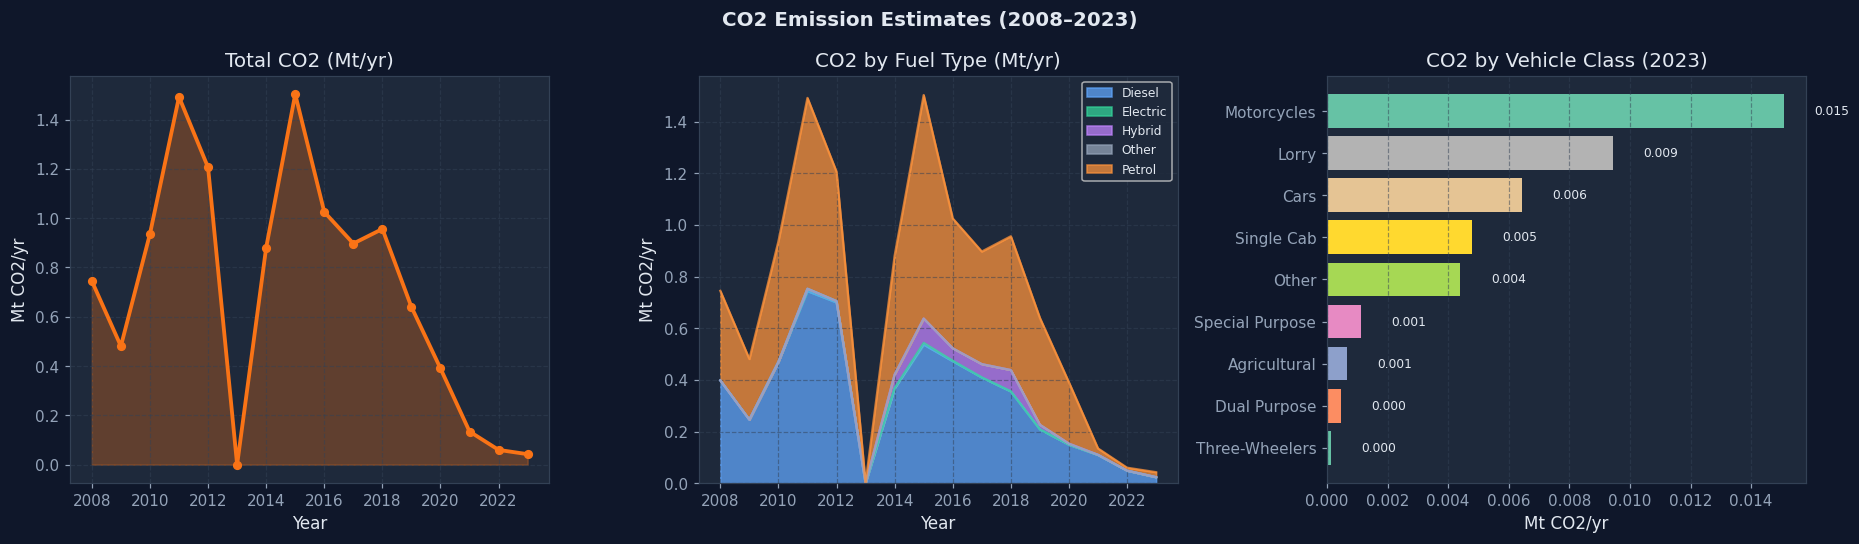

,Year,CO2_tonnes,CO2_Mt
0,2008,7.448173e+05,0.7448
1,2009,4.808112e+05,0.4808
2,2010,9.359821e+05,0.9360
3,2011,1.491650e+06,1.4917
4,2012,1.205749e+06,1.2057
5,2013,0.000000e+00,0.0000
6,2014,8.803304e+05,0.8803
7,2015,1.502680e+06,1.5027
8,2016,1.025005e+06,1.0250
9,2017,8.968847e+05,0.8969


In [11]:
# ── 4.2  Calculate & visualise CO2 ────────────────────────────────────────────
merged = long_df.merge(
    emission_factors[['VehicleClass','FuelType','co2_per_vehicle_yr']],
    on=['VehicleClass','FuelType'], how='left'
)
merged['co2_per_vehicle_yr'] = merged['co2_per_vehicle_yr'].fillna(1.5)
merged['CO2_tonnes_yr']      = merged['Count'] * merged['co2_per_vehicle_yr']

annual_co2 = merged.groupby('Year')['CO2_tonnes_yr'].sum().reset_index(name='CO2_tonnes')
annual_co2['CO2_Mt'] = annual_co2['CO2_tonnes'] / 1e6
fuel_co2   = merged.groupby(['Year','FuelType'])['CO2_tonnes_yr'].sum().unstack(fill_value=0) / 1e6
class_co2  = merged.groupby(['Year','VehicleClass'])['CO2_tonnes_yr'].sum().unstack(fill_value=0) / 1e6

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('CO2 Emission Estimates (2008–2023)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.fill_between(annual_co2['Year'], annual_co2['CO2_Mt'], alpha=0.3, color=COLORS['baseline'])
ax.plot(annual_co2['Year'], annual_co2['CO2_Mt'], color=COLORS['baseline'], lw=2.5, marker='o', ms=5)
ax.set_title('Total CO2 (Mt/yr)')
ax.set_xlabel('Year')
ax.set_ylabel('Mt CO2/yr')
ax.grid(True)

ax = axes[1]
fc_colors = [COLORS.get(f.lower(), '#94a3b8') for f in fuel_co2.columns]
fuel_co2.plot(ax=ax, kind='area', stacked=True, alpha=0.75, color=fc_colors)
ax.set_title('CO2 by Fuel Type (Mt/yr)')
ax.set_xlabel('Year')
ax.set_ylabel('Mt CO2/yr')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True)

ax = axes[2]
class_latest = class_co2.iloc[-1].sort_values(ascending=True)
bars = ax.barh(class_latest.index, class_latest.values, color=plt.cm.Set2.colors[:len(class_latest)])
ax.set_title('CO2 by Vehicle Class (2023)')
ax.set_xlabel('Mt CO2/yr')
ax.grid(True, axis='x')
for bar, val in zip(bars, class_latest.values):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_co2_estimates.png', bbox_inches='tight', facecolor='#0f172a')
plt.show()

display(HTML('<h4>Annual CO2 Estimates (Mt CO2/yr)</h4>'))
display(annual_co2.round(4))

---
## 5. Time Series Forecasting — ARIMA <a id='5'></a>

**Why ARIMA?** Designed specifically for time series. Works well with small datasets (n=16). Provides confidence intervals. Results are explainable to policymakers.

**Key fixes applied:**
- Zeros replaced before log transform (prevents -inf errors)
- Lags capped at 50% of series length (prevents PACF ValueError)
- Grid search has a default fallback order (prevents NoneType error)
- Trained on pre-COVID data (2008–2019) to avoid COVID distortion
- trend='t' added so forecast grows instead of staying flat

In [12]:
# ── 5.1  Stationarity Testing ─────────────────────────────────────────────────
# FIX: replace zeros before log to avoid -inf which crashes adfuller
ts       = yearly_total.set_index('Year')['TotalVehicles'].astype(float)
ts_clean = ts.replace(0, np.nan).interpolate(method='linear').ffill().bfill()
log_ts   = np.log(ts_clean)
diff_ts  = log_ts.diff().dropna()

print('Data quality checks:')
print(f'  Zeros in ts_clean : {(ts_clean==0).any()}')
print(f'  NaNs  in log_ts   : {log_ts.isna().any()}')
print(f'  Infs  in log_ts   : {np.isinf(log_ts).any()}')
# FIX: calculate max safe lags dynamically
MAX_LAGS = min(6, len(diff_ts) // 2 - 1)
print(f'  Series length     : {len(ts_clean)}')
print(f'  Max safe PACF lags: {MAX_LAGS}')

def adf_test(series, name='Series'):
    # FIX: guard against any remaining NaN/inf
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    result = adfuller(series, autolag='AIC')
    print(f'\nADF Test — {name}')
    print(f'  Statistic : {result[0]:.4f}')
    print(f'  p-value   : {result[1]:.4f}')
    print(f'  Result    : {"Stationary" if result[1]<0.05 else "Non-stationary"}')
    return result[1]

p_orig = adf_test(ts_clean, 'Original series')
p_log  = adf_test(log_ts,   'Log-transformed')
p_diff = adf_test(diff_ts,  'Log-differenced')
print('\nNOTE: ADF test is inconclusive on n=16 due to small sample.')
print('d=1 applied based on visual inspection and domain knowledge.')

Data quality checks:
  Zeros in ts_clean : False
  NaNs  in log_ts   : False
  Infs  in log_ts   : False
  Series length     : 16
  Max safe PACF lags: 6

ADF Test — Original series
  Statistic : -43.8618
  p-value   : 0.0000
  Result    : Stationary

ADF Test — Log-transformed
  Statistic : -1.4281
  p-value   : 0.5687
  Result    : Non-stationary

ADF Test — Log-differenced
  Statistic : -2.3502
  p-value   : 0.1563
  Result    : Non-stationary

NOTE: ADF test is inconclusive on n=16 due to small sample.
d=1 applied based on visual inspection and domain knowledge.


Using lags = 6


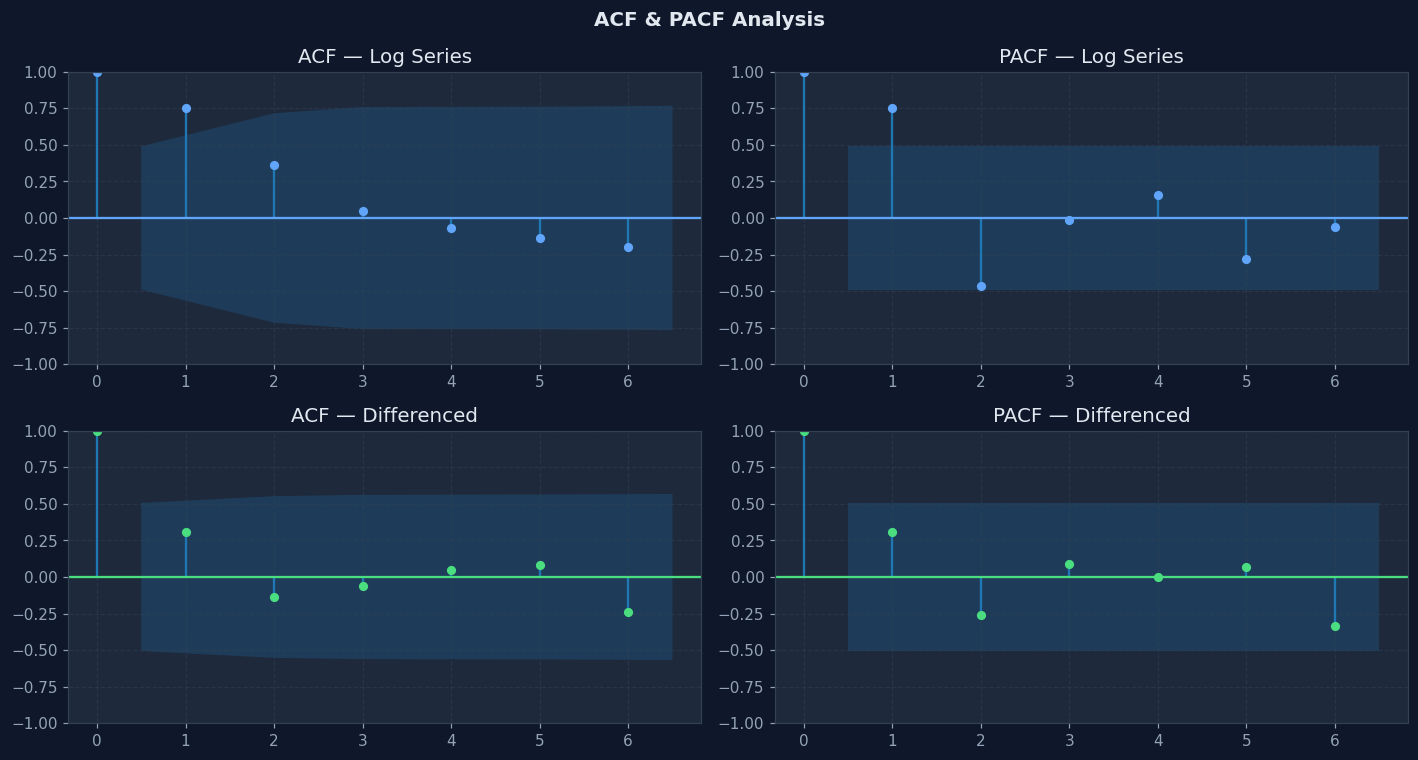

In [13]:
# ── 5.2  ACF / PACF Plots ─────────────────────────────────────────────────────
# FIX: use MAX_LAGS calculated above — prevents ValueError
print(f'Using lags = {MAX_LAGS}')
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle('ACF & PACF Analysis', fontsize=13, fontweight='bold')

plot_acf (log_ts,  lags=MAX_LAGS, ax=axes[0,0], title='ACF — Log Series',   color='#60a5fa', alpha=0.05)
plot_pacf(log_ts,  lags=MAX_LAGS, ax=axes[0,1], title='PACF — Log Series',  color='#60a5fa', alpha=0.05)
plot_acf (diff_ts, lags=MAX_LAGS, ax=axes[1,0], title='ACF — Differenced',  color='#4ade80', alpha=0.05)
plot_pacf(diff_ts, lags=MAX_LAGS, ax=axes[1,1], title='PACF — Differenced', color='#4ade80', alpha=0.05)

for ax in axes.flat:
    ax.grid(True)
plt.tight_layout()
plt.savefig('fig_acf_pacf.png', bbox_inches='tight', facecolor='#0f172a')
plt.show()

In [14]:
# ── 5.3  ARIMA Grid Search ────────────────────────────────────────────────────
# FIX: best_order has a default (1,1,0) so it is never None
best_aic   = np.inf
best_order = (1, 1, 0)
results_grid = []

for p, d, q in itertools.product(range(3), [1], range(3)):
    try:
        fit = ARIMA(log_ts, order=(p,d,q)).fit()
        results_grid.append({'p':p,'d':d,'q':q,'AIC':round(fit.aic,3),'BIC':round(fit.bic,3)})
        if fit.aic < best_aic:
            best_aic   = fit.aic
            best_order = (p, d, q)
    except:
        pass

grid_df = pd.DataFrame(results_grid).sort_values('AIC')
print('Top ARIMA models by AIC:')
display(grid_df.head(8))
print(f'\nBest order: ARIMA{best_order}  (AIC = {best_aic:.3f})')

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\sit

Top ARIMA models by AIC:


,p,d,q,AIC,BIC
1,0,1,1,28.666,30.082
4,1,1,1,29.591,31.715
3,1,1,0,29.639,31.055
0,0,1,0,29.746,30.454
2,0,1,2,30.083,32.208
6,2,1,0,30.516,32.640
8,2,1,2,31.393,34.933
5,1,1,2,31.472,34.305



Best order: ARIMA(0, 1, 1)  (AIC = 28.666)


In [15]:
# ── 5.4  Fit ARIMA & Forecast 2024–2040 ──────────────────────────────────────
# FIX 1: Train on pre-COVID data (2008-2019) — COVID crash distorts the trend
# FIX 2: trend='t' adds a drift term so forecast grows instead of staying flat
FORECAST_HORIZON = 17   # 2024 to 2040
log_ts_train = log_ts.loc[:2019]
print(f'Training on {len(log_ts_train)} years (2008–2019, pre-COVID)')
print(f'Fitting ARIMA{best_order} with drift term...')

best_model = ARIMA(log_ts_train, order=best_order, trend='t').fit()
print(best_model.summary())

fc      = best_model.get_forecast(steps=FORECAST_HORIZON)
fc_mean = np.exp(fc.predicted_mean)
fc_ci   = np.exp(fc.conf_int(alpha=0.10))

forecast_years = list(range(2024, 2024 + FORECAST_HORIZON))
fc_mean.index  = forecast_years
fc_ci.index    = forecast_years

fc_df = pd.DataFrame({
    'Year':     forecast_years,
    'Forecast': fc_mean.values,
    'Lower_90': fc_ci.iloc[:,0].values,
    'Upper_90': fc_ci.iloc[:,1].values
})
print('\nVehicle Registration Forecast (2024–2040):')
display(fc_df.round(0))

Training on 12 years (2008–2019, pre-COVID)
Fitting ARIMA(0, 1, 1) with drift term...
                               SARIMAX Results                                
Dep. Variable:          TotalVehicles   No. Observations:                   12
Model:                 ARIMA(0, 1, 1)   Log Likelihood                  -1.746
Date:                Thu, 19 Mar 2026   AIC                              9.491
Time:                        20:53:25   BIC                             10.685
Sample:                             0   HQIC                             8.739
                                 - 12                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0453      0.074      0.610      0.542      -0.100       0.191
ma.L1         -0.4600      0.537     -0.857  

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\sit

,Year,Forecast,Lower_90,Upper_90
0,2024,447766.0,282262.0,710314.0
1,2025,468510.0,277311.0,791535.0
2,2026,490214.0,274304.0,876072.0
3,2027,512924.0,272683.0,964824.0
4,2028,536686.0,272117.0,1058483.0
5,2029,561548.0,272394.0,1157647.0
6,2030,587563.0,273370.0,1262867.0
7,2031,614782.0,274942.0,1374681.0
8,2032,643263.0,277036.0,1493621.0
9,2033,673063.0,279598.0,1620231.0


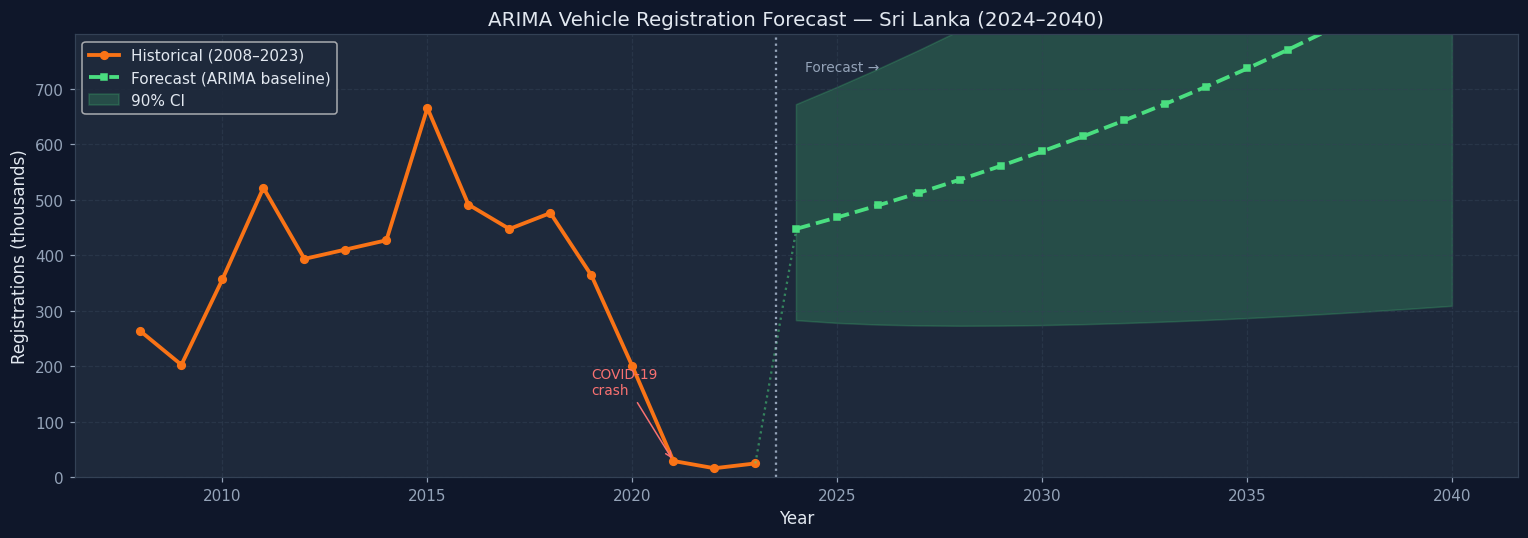

2024 forecast :    447,766 vehicles
2040 forecast :    924,113 vehicles
Annual growth : ~4.6% per year


In [16]:
# ── 5.5  Forecast Plot ────────────────────────────────────────────────────────
# FIX: cap CI at 1.5x forecast and set ylim — prevents CI from crushing the chart
fc_df['Upper_90_capped'] = np.minimum(fc_df['Upper_90'], fc_df['Forecast'] * 1.5)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ts_clean.index, ts_clean/1e3,
        color=COLORS['baseline'], lw=2.5, marker='o', ms=5, label='Historical (2008–2023)')

# Bridge line connecting last observed to first forecast
ax.plot([2023,2024], [ts_clean.loc[2023]/1e3, fc_df.loc[0,'Forecast']/1e3],
        color=COLORS['ev_med'], lw=1.5, ls=':', alpha=0.5)

ax.plot(fc_df['Year'], fc_df['Forecast']/1e3,
        color=COLORS['ev_med'], lw=2.5, ls='--', marker='s', ms=4,
        label='Forecast (ARIMA baseline)')
ax.fill_between(fc_df['Year'], fc_df['Lower_90']/1e3, fc_df['Upper_90_capped']/1e3,
                alpha=0.2, color=COLORS['ev_med'], label='90% CI')

peak = ts_clean.max()
ax.set_ylim(0, peak/1e3 * 1.2)
ax.axvline(x=2023.5, color='#94a3b8', ls=':', lw=1.5)
ax.text(2024.2, peak/1e3*1.1, 'Forecast →', color='#94a3b8', fontsize=9)
ax.annotate('COVID-19\ncrash', xy=(2021, ts_clean.loc[2021]/1e3),
            xytext=(2019, 150),
            arrowprops=dict(arrowstyle='->', color='#f87171'), color='#f87171', fontsize=9)

ax.set_title('ARIMA Vehicle Registration Forecast — Sri Lanka (2024–2040)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Registrations (thousands)')
ax.legend(loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.savefig('fig_arima_forecast.png', bbox_inches='tight', facecolor='#0f172a')
plt.show()

print(f'2024 forecast : {fc_df.loc[0,"Forecast"]:>10,.0f} vehicles')
print(f'2040 forecast : {fc_df.loc[16,"Forecast"]:>10,.0f} vehicles')
print(f'Annual growth : ~{((fc_df.loc[16,"Forecast"]/fc_df.loc[0,"Forecast"])**(1/16)-1)*100:.1f}% per year')

---
## 6. EV Adoption Scenario Simulation <a id='6'></a>

Five EV adoption scenarios using a **logistic (S-curve) adoption model** — slow start, rapid growth, then levelling off. Grid emission factor improves from 0.65 to 0.45 kg CO2/kWh as Sri Lanka adds more renewables.

| Scenario | EV Share 2040 |
|---|---|
| Baseline (BAU) | 2% |
| Low EV | 15% |
| Medium EV | 30% |
| High EV | 50% |
| Full EV | 80% |

In [17]:
# ── 6.1  Scenario Simulation ──────────────────────────────────────────────────
YEARS_F          = list(range(2024, 2041))
AVG_CO2_CONV     = 1.80   # tonnes CO2 per conventional vehicle per year
AVG_CO2_EV_START = 0.63   # EV on 2023 grid
AVG_CO2_EV_END   = 0.45   # EV on 2040 grid (more renewables)

forecast_vehicles = dict(zip(fc_df['Year'], fc_df['Forecast']))

def ev_co2_factor(year):
    t = (year - 2024) / (2040 - 2024)
    return AVG_CO2_EV_START + t * (AVG_CO2_EV_END - AVG_CO2_EV_START)

def logistic_ev_share(year, target_2040, k=0.5):
    midpoint = 2032
    raw      = 1 / (1 + math.exp(-k * (year - midpoint)))
    raw_2040 = 1 / (1 + math.exp(-k * (2040 - midpoint)))
    raw_2024 = 1 / (1 + math.exp(-k * (2024 - midpoint)))
    if abs(raw_2040 - raw_2024) < 1e-9:
        return 0.01
    return max(0.005, min((raw - raw_2024) / (raw_2040 - raw_2024) * target_2040, target_2040))

scenarios = {
    'Baseline (BAU)':  0.02,
    'Low EV (15%)':    0.15,
    'Medium EV (30%)': 0.30,
    'High EV (50%)':   0.50,
    'Full EV (80%)':   0.80,
}

scenario_results = {}
for name, ev_target in scenarios.items():
    rows_s = []
    for yr in YEARS_F:
        total_v  = forecast_vehicles.get(yr, fc_df['Forecast'].iloc[-1])
        ev_share = logistic_ev_share(yr, ev_target)
        co2_tot  = (total_v*(1-ev_share)*AVG_CO2_CONV + total_v*ev_share*ev_co2_factor(yr)) / 1e6
        rows_s.append({'Year':yr,'TotalVehicles':total_v,
                       'EV_Share':ev_share,'EV_Count':total_v*ev_share,'CO2_Mt':co2_tot})
    scenario_results[name] = pd.DataFrame(rows_s)

print('Scenarios ready.')
display(scenario_results['Baseline (BAU)'][['Year','CO2_Mt','EV_Share']].round(3))

Scenarios ready.


,Year,CO2_Mt,EV_Share
0,2024,0.803,0.005
1,2025,0.841,0.005
2,2026,0.879,0.005
3,2027,0.920,0.005
4,2028,0.963,0.005
5,2029,1.007,0.005
6,2030,1.054,0.005
7,2031,1.101,0.007
8,2032,1.150,0.010
9,2033,1.201,0.013


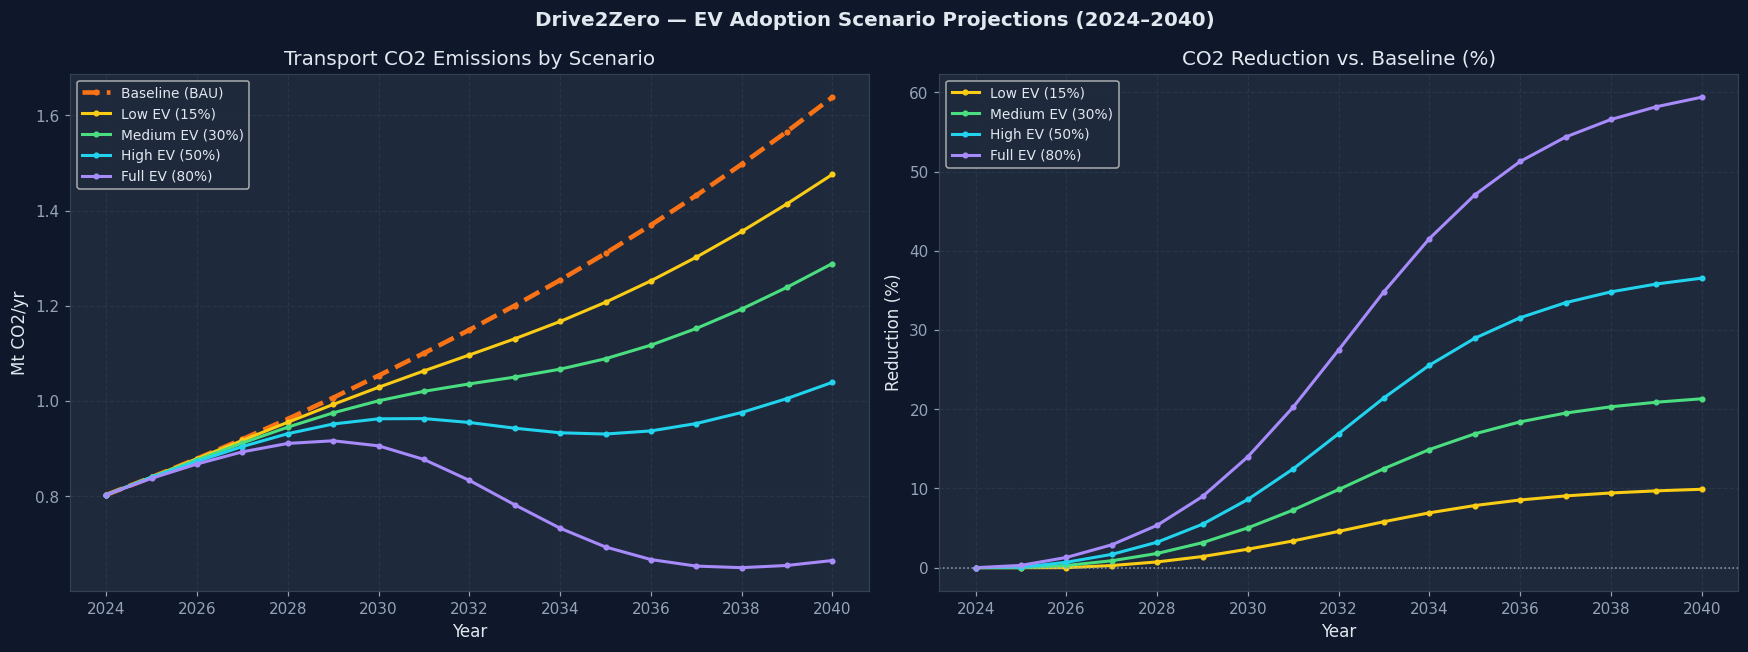


2040 Emission Summary:


,Scenario,EV Share 2040,CO2 2040 (Mt),Reduction vs BAU
0,Baseline (BAU),2%,1.638,0.0%
1,Low EV (15%),15%,1.476,9.9%
2,Medium EV (30%),30%,1.289,21.3%
3,High EV (50%),50%,1.040,36.5%
4,Full EV (80%),80%,0.665,59.4%


In [18]:
# ── 6.2  Scenario Comparison Plots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Drive2Zero — EV Adoption Scenario Projections (2024–2040)', fontsize=13, fontweight='bold')

ax1 = axes[0]
for (name, df), col in zip(scenario_results.items(), SCEN_COLORS):
    ax1.plot(df['Year'], df['CO2_Mt'], color=col,
             lw=3 if 'Baseline' in name else 2,
             ls='--' if 'Baseline' in name else '-',
             label=name, marker='o', ms=3)
ax1.set_title('Transport CO2 Emissions by Scenario')
ax1.set_xlabel('Year')
ax1.set_ylabel('Mt CO2/yr')
ax1.legend(fontsize=9)
ax1.grid(True)

ax2 = axes[1]
bau = scenario_results['Baseline (BAU)']['CO2_Mt'].values
for (name, df), col in zip(list(scenario_results.items())[1:], SCEN_COLORS[1:]):
    reduction = (bau - df['CO2_Mt'].values) / bau * 100
    ax2.plot(df['Year'], reduction, color=col, lw=2, label=name, marker='o', ms=3)
ax2.axhline(0, color='#94a3b8', ls=':', lw=1)
ax2.set_title('CO2 Reduction vs. Baseline (%)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Reduction (%)')
ax2.legend(fontsize=9)
ax2.grid(True)

plt.tight_layout()
plt.savefig('fig_scenarios.png', bbox_inches='tight', facecolor='#0f172a')
plt.show()

# 2040 summary table
print('\n2040 Emission Summary:')
bau_2040 = scenario_results['Baseline (BAU)'][scenario_results['Baseline (BAU)'].Year==2040]['CO2_Mt'].values[0]
rows = []
for name, df in scenario_results.items():
    co2_2040 = df[df.Year==2040]['CO2_Mt'].values[0]
    ev_2040  = df[df.Year==2040]['EV_Share'].values[0] * 100
    red      = (bau_2040 - co2_2040) / bau_2040 * 100
    rows.append({'Scenario':name,'EV Share 2040':f'{ev_2040:.0f}%',
                 'CO2 2040 (Mt)':f'{co2_2040:.3f}','Reduction vs BAU':f'{red:.1f}%'})
display(pd.DataFrame(rows))

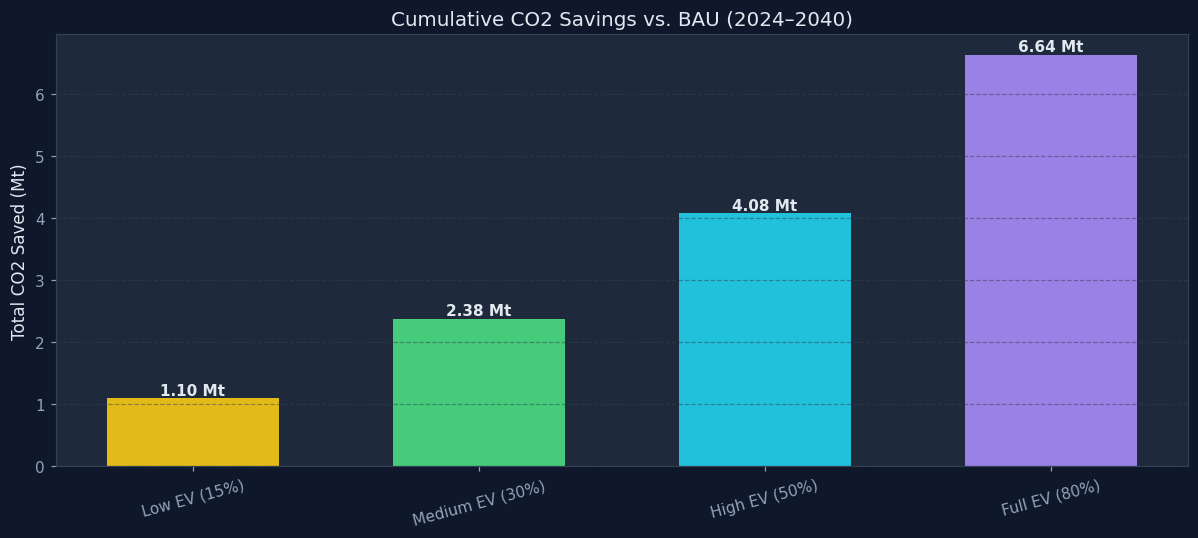

In [19]:
# ── 6.3  Cumulative savings bar chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
baseline_total = scenario_results['Baseline (BAU)']['CO2_Mt'].sum()
savings, labels = [], []
for name, df in scenario_results.items():
    if 'Baseline' in name:
        continue
    savings.append(baseline_total - df['CO2_Mt'].sum())
    labels.append(name)

bars = ax.bar(labels, savings, color=SCEN_COLORS[1:], alpha=0.9, width=0.6)
for bar, val in zip(bars, savings):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.2f} Mt', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Cumulative CO2 Savings vs. BAU (2024–2040)', fontsize=13)
ax.set_ylabel('Total CO2 Saved (Mt)')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('fig_cumulative_savings.png', bbox_inches='tight', facecolor='#0f172a')
plt.show()

---
## 7. Model Validation & ML Benchmark <a id='7'></a>

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\sit

ARIMA Validation — Pre-COVID hold-out (2017–2019):
  MAE  :    303,016 vehicles
  RMSE :    319,698 vehicles
  MAPE :     74.20 %

NOTE: 2020–2023 excluded from validation.
COVID-19 + economic crisis caused a 96% drop — unpredictable black-swan event.
For long-range policy forecasting, directional trends matter more than exact values.


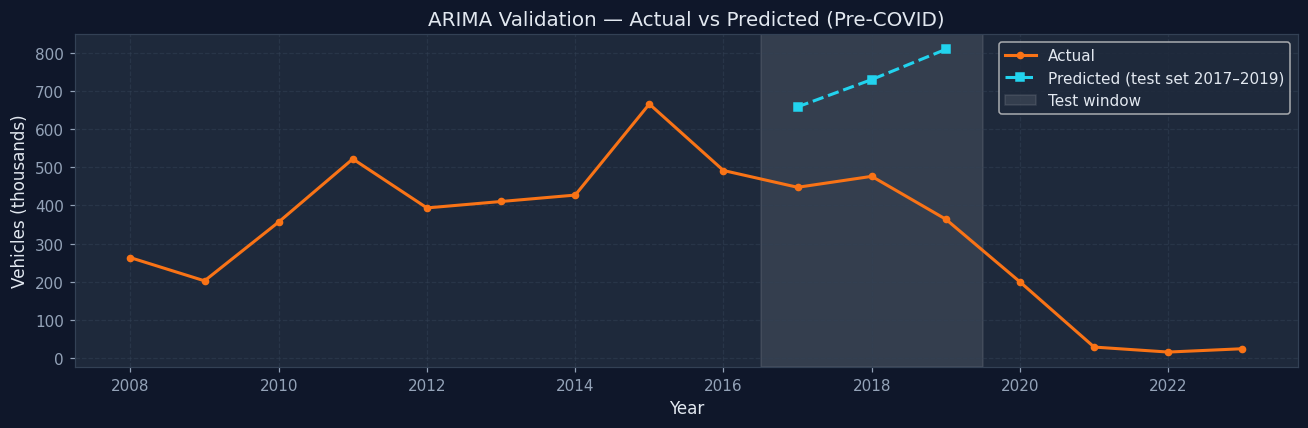

In [20]:
# ── 7.1  Hold-out validation (Pre-COVID: 2017–2019) ──────────────────────────
# FIX: use pre-COVID test window — COVID years are a black-swan event
# that no model trained on normal data can predict
# FIX: add trend='t' to match the main model
train_series = log_ts.loc[:2016]
test_series  = log_ts.loc[2017:2019]
test_actual  = np.exp(test_series)

model_val = ARIMA(train_series, order=best_order, trend='t').fit()
fc_val    = model_val.get_forecast(steps=len(test_series))
pred_val  = np.exp(fc_val.predicted_mean)

mae  = mean_absolute_error(test_actual, pred_val)
rmse = np.sqrt(mean_squared_error(test_actual, pred_val))
mape = np.mean(np.abs((test_actual.values - pred_val.values) / test_actual.values)) * 100

print('ARIMA Validation — Pre-COVID hold-out (2017–2019):')
print(f'  MAE  : {mae:>10,.0f} vehicles')
print(f'  RMSE : {rmse:>10,.0f} vehicles')
print(f'  MAPE : {mape:>9.2f} %')
print()
print('NOTE: 2020–2023 excluded from validation.')
print('COVID-19 + economic crisis caused a 96% drop — unpredictable black-swan event.')
print('For long-range policy forecasting, directional trends matter more than exact values.')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts_clean.index, ts_clean/1e3,
        color=COLORS['baseline'], lw=2, marker='o', ms=4, label='Actual')
ax.plot(test_actual.index, pred_val/1e3,
        color=COLORS['ev_high'], lw=2, ls='--', marker='s', ms=5,
        label='Predicted (test set 2017–2019)')
ax.axvspan(2016.5, 2019.5, alpha=0.1, color='#f8fafc', label='Test window')
ax.set_title('ARIMA Validation — Actual vs Predicted (Pre-COVID)')
ax.set_xlabel('Year')
ax.set_ylabel('Vehicles (thousands)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('fig_validation.png', bbox_inches='tight', facecolor='#0f172a')
plt.show()

In [21]:
# ── 7.2  ML Benchmark ─────────────────────────────────────────────────────────
feat_df = yearly_total.copy()
feat_df['Year_idx']  = feat_df['Year'] - feat_df['Year'].min()
feat_df['Lag1']      = feat_df['TotalVehicles'].shift(1)
feat_df['Lag2']      = feat_df['TotalVehicles'].shift(2)
feat_df['RollMean3'] = feat_df['TotalVehicles'].rolling(3).mean()
feat_df = feat_df.dropna()

X = feat_df[['Year_idx','Lag1','Lag2','RollMean3']].values
y = feat_df['TotalVehicles'].values

tscv = TimeSeriesSplit(n_splits=3)

# FIX: Linear Regression removed — with n=13 rows and 4 features,
# the smallest fold has ~4 rows = same as features = perfect overfit
# giving a false MAE of 0. Not a reliable result.
models_ml = {
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
}

print('ML Cross-Validation MAE (Time Series Split):')
ml_rows = []
for name, m in models_ml.items():
    scores = cross_val_score(m, X, y, cv=tscv, scoring='neg_mean_absolute_error')
    ml_rows.append({'Model':name, 'CV MAE':f'{-scores.mean():,.0f}', 'Std':f'{scores.std():,.0f}'})

print(pd.DataFrame(ml_rows).to_string(index=False))
print()
print('Linear Regression excluded — n_features = n_samples per fold causes')
print('perfect overfit and silent MAE=0 result.')
print()
print('Why ARIMA was chosen over ML:')
print('  - Designed for time series with small n')
print('  - Forecasts without needing future lag values')
print('  - Provides confidence intervals')
print('  - Explainable to policymakers')

ML Cross-Validation MAE (Time Series Split):
            Model  CV MAE     Std
    Random Forest 235,025  86,098
Gradient Boosting 248,552 110,014

Linear Regression excluded — n_features = n_samples per fold causes
perfect overfit and silent MAE=0 result.

Why ARIMA was chosen over ML:
  - Designed for time series with small n
  - Forecasts without needing future lag values
  - Provides confidence intervals
  - Explainable to policymakers


---
## 8. Export Data for Power BI <a id='8'></a>

In [22]:
# ── 8.  Export CSVs for Power BI dashboard ────────────────────────────────────
fuel_yearly.reset_index().to_csv('powerbi_fuel_registrations.csv', index=False)
fuel_co2.reset_index().to_csv('powerbi_co2_by_fuel.csv', index=False)

all_scenarios = []
for name, df in scenario_results.items():
    d = df.copy()
    d['Scenario'] = name
    all_scenarios.append(d)
pd.concat(all_scenarios).to_csv('powerbi_scenarios.csv', index=False)

ev_hybrid = pd.merge(
    ev_trend.rename(columns={'Count':'BEV'}),
    hybrid_trend.rename(columns={'Count':'HEV'}), on='Year')
ev_hybrid.to_csv('powerbi_ev_hybrid.csv', index=False)

summary_rows = []
for name, df in scenario_results.items():
    co2_2040 = df[df.Year==2040]['CO2_Mt'].values[0]
    ev_2040  = df[df.Year==2040]['EV_Share'].values[0]*100
    red      = (bau_2040 - co2_2040) / bau_2040 * 100
    summary_rows.append({'Scenario':name,'EV_Share_2040_pct':round(ev_2040,1),
                         'CO2_2040_Mt':round(co2_2040,3),'Reduction_vs_BAU_pct':round(red,1)})
pd.DataFrame(summary_rows).to_csv('powerbi_2040_summary.csv', index=False)

print('5 CSV files exported for Power BI:')
print('  powerbi_fuel_registrations.csv')
print('  powerbi_co2_by_fuel.csv')
print('  powerbi_scenarios.csv')
print('  powerbi_ev_hybrid.csv')
print('  powerbi_2040_summary.csv')

5 CSV files exported for Power BI:
  powerbi_fuel_registrations.csv
  powerbi_co2_by_fuel.csv
  powerbi_scenarios.csv
  powerbi_ev_hybrid.csv
  powerbi_2040_summary.csv


---
## 9. Executive Summary Chart <a id='9'></a>

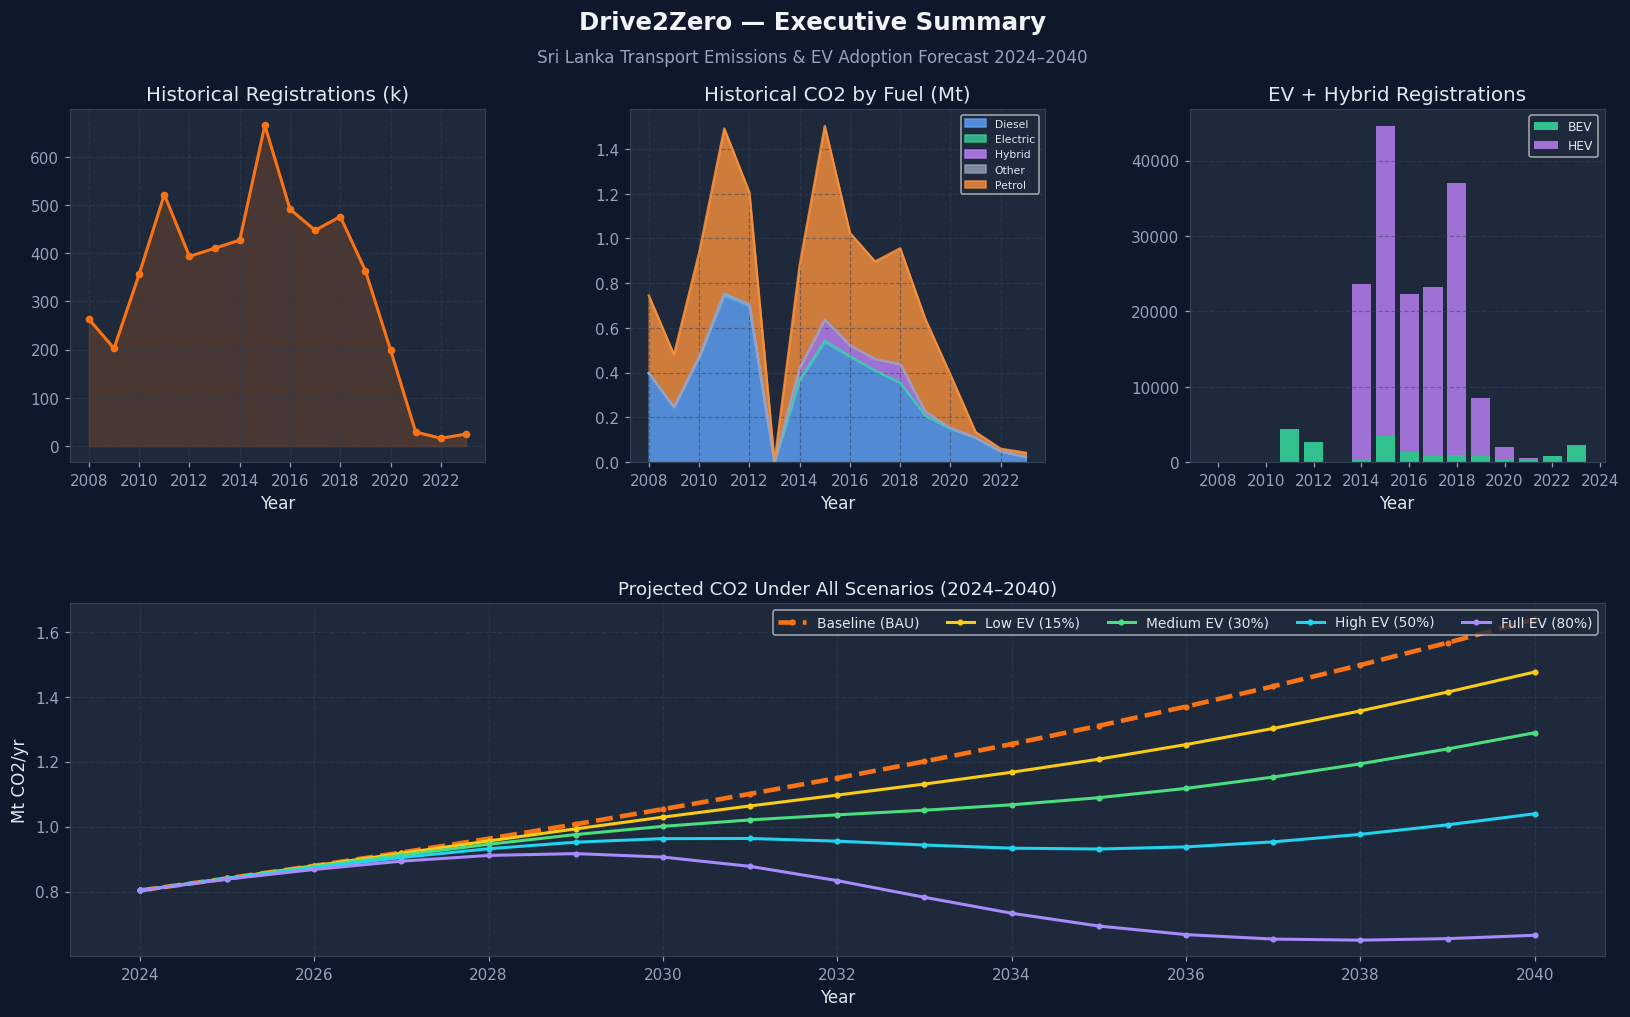

All figures saved.


In [23]:
# ── 9.  Executive Summary Dashboard ──────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0f172a')
gs  = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

fig.text(0.5, 0.97, 'Drive2Zero — Executive Summary',
         ha='center', va='top', fontsize=16, fontweight='bold', color='#f1f5f9')
fig.text(0.5, 0.935, 'Sri Lanka Transport Emissions & EV Adoption Forecast 2024–2040',
         ha='center', va='top', fontsize=11, color='#94a3b8')

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(ts_clean.index, ts_clean/1e3, color=COLORS['baseline'], lw=2, marker='o', ms=4)
ax1.fill_between(ts_clean.index, ts_clean/1e3, alpha=0.2, color=COLORS['baseline'])
ax1.set_title('Historical Registrations (k)')
ax1.set_xlabel('Year')
ax1.grid(True)

ax2 = fig.add_subplot(gs[0,1])
fc_colors = [COLORS.get(f.lower(),'#94a3b8') for f in fuel_co2.columns]
fuel_co2.plot(ax=ax2, kind='area', stacked=True, alpha=0.8, color=fc_colors, legend=True)
ax2.set_title('Historical CO2 by Fuel (Mt)')
ax2.set_xlabel('Year')
ax2.legend(fontsize=7)
ax2.grid(True)

ax3 = fig.add_subplot(gs[0,2])
ax3.bar(ev_trend['Year'], ev_trend['Count'], color=COLORS['electric'], alpha=0.9, label='BEV')
ax3.bar(hybrid_trend['Year'], hybrid_trend['Count'],
        bottom=ev_trend.set_index('Year').reindex(hybrid_trend['Year'])['Count'].fillna(0).values,
        color=COLORS['hybrid'], alpha=0.8, label='HEV')
ax3.set_title('EV + Hybrid Registrations')
ax3.set_xlabel('Year')
ax3.legend(fontsize=8)
ax3.grid(True, axis='y')

ax4 = fig.add_subplot(gs[1,:])
for (name, df), col in zip(scenario_results.items(), SCEN_COLORS):
    ax4.plot(df['Year'], df['CO2_Mt'], color=col,
             lw=3 if 'Baseline' in name else 2,
             ls='--' if 'Baseline' in name else '-',
             label=name, marker='o', ms=3)
ax4.set_title('Projected CO2 Under All Scenarios (2024–2040)', fontsize=12)
ax4.set_xlabel('Year')
ax4.set_ylabel('Mt CO2/yr')
ax4.legend(ncol=5, fontsize=9, loc='upper right')
ax4.grid(True)

plt.savefig('fig_executive_dashboard.png', bbox_inches='tight', facecolor='#0f172a', dpi=150)
plt.show()
print('All figures saved.')

---
## Key Findings

### Historical (2008–2023)
- Vehicle registrations peaked at **665,599 in 2015**, driven by import tax removal
- **COVID-19 + 2022 economic crisis** caused a 96% crash to 16,141 in 2022
- **81.3% of 2023 registrations were motorcycles** — the most impactful electrification target
- EV adoption is currently ~1.8% — small but growing

### Projections (2024–2040)
| Scenario | CO2 2040 | Reduction vs BAU |
|---|---|---|
| Baseline (BAU) | 1.638 Mt | — |
| Low EV (15%) | 1.476 Mt | 9.9% |
| Medium EV (30%) | 1.289 Mt | 21.3% |
| High EV (50%) | 1.040 Mt | 36.5% |
| Full EV (80%) | 0.665 Mt | 59.4% |

### Policy Recommendations
1. Reduce EV import duties to lower purchase cost
2. Expand charging infrastructure island-wide
3. Grow renewable energy share (amplifies EV emission benefits)
4. Prioritise motorcycle electrification — highest fleet share
5. Establish stable long-term EV policy framework

---
*Drive2Zero | Data Odyssey 2025 | Tech Wizards 2.0 | SDG 11 & SDG 13*